# 电子产品销售分析 - 项目拆解与理解笔记

## 项目背景
基于电商电子产品销售数据，从用户、产品、销售、会员等维度拆解，输出运营优化建议。

## 核心目标
1. 跑通全部分析逻辑
2. 理解每一步操作的业务意义
3. 标记可拓展的分析点

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Notebook 专用：让图表内嵌显示
%matplotlib inline

# 引用项目的字体配置，保持风格统一
import sys
sys.path.append("..")
from src.utils.plot_config import set_matplotlib_style
set_matplotlib_style()

## 一、数据加载与清洗
### 思考问题
1. 原始数据有哪些字段？分别代表什么业务含义？
2. 需要做哪些清洗操作？分别解决什么问题？
3. 如果不做这些清洗，会对后续分析造成什么影响？

In [2]:
# 读取数据
df_path = "../data/raw/electronics_sales.csv"
df_u = pd.read_csv(df_path)
print("原始数据形状：", df_u.shape)
df_u.head(3)

原始数据形状： (564169, 12)


,Unnamed: 0,event_time,order_id,product_id,category_id,category_code,brand,price,user_id,age,sex,local
0,0,2020-04-24 11:50:39 UTC,2294359932054536986,1515966223509089906,2.268105e+18,electronics.tablet,samsung,162.01,1.515916e+18,24.0,女,海南
1,1,2020-04-24 11:50:39 UTC,2294359932054536986,1515966223509089906,2.268105e+18,electronics.tablet,samsung,162.01,1.515916e+18,24.0,女,海南
2,2,2020-04-24 14:37:43 UTC,2294444024058086220,2273948319057183658,2.268105e+18,electronics.audio.headphone,huawei,77.52,1.515916e+18,38.0,女,北京


In [3]:
# 1. 删除无用列
del df_u['category_code']

# 2. 品牌缺失值填充
df_u.fillna('no_brand',inplace = True)

# 3. 按订单ID去重
df_u = df_u.drop_duplicates('order_id')

# 4. 时间字段修正
df_u['event_time'] = df_u['event_time'].str.replace('1970','2020')
df_u['event_time'] = pd.to_datetime(df_u['event_time']).dt.to_period('D')

# 5. 设置时间索引，新增月份字段
df_u = df_u.set_index('event_time',drop = False)
df_u['month'] = df_u['event_time'].dt.month

df = df_u
print("清洗后数据形状：", df.shape)
df.head(3)

清洗后数据形状： (400538, 12)


,Unnamed: 0,event_time,order_id,product_id,category_id,brand,price,user_id,age,sex,local,month
event_time,,,,,,,,,,,,
2020-04-24,0,2020-04-24,2294359932054536986,1515966223509089906,2.268105e+18,samsung,162.01,1.515916e+18,24.0,女,海南,4
2020-04-24,2,2020-04-24,2294444024058086220,2273948319057183658,2.268105e+18,huawei,77.52,1.515916e+18,38.0,女,北京,4
2020-04-24,4,2020-04-24,2294584263154074236,2273948316817424439,2.268105e+18,karcher,217.57,1.515916e+18,32.0,女,广东,4


### 初步理解
1. 删除 category_code 列：该字段无有效业务信息，属于冗余字段，删除后减少数据量。
2. 品牌填充为 no_brand：避免后续按品牌分组统计时，空值被忽略，保证数据完整性。
3. 按 order_id 去重：防止同一订单被重复统计，导致销售额、订单量虚高。
4. 时间替换 1970→2020：原始数据时间异常，修正后才能做正确的时间维度分析。

### 待验证疑问
- 为什么用 order_id 去重，而不是 user_id + 时间？
- 有没有其他缺失值、异常值没有处理？

二、用户 AB 分层
🤔 思考问题
为什么要做用户分层？不分层直接全量分析会有什么问题？
选 30 单 作为 A、B 类用户的分界？这个阈值合理吗？
A 类用户和 B 类用户分别对应什么业务人群？为什么分析重点放在 B 类用户上？

用户订单数分布描述：
count    93823.000000
mean         4.269081
std         18.192114
min          1.000000
25%          1.000000
50%          2.000000
75%          3.000000
max        666.000000
Name: order_id, dtype: float64

用户分层统计：
A类用户数：1044，占比：1.11%
B类用户数：92779，占比：98.89%
A类用户贡献销售额：21707473.21，占比：22.67%


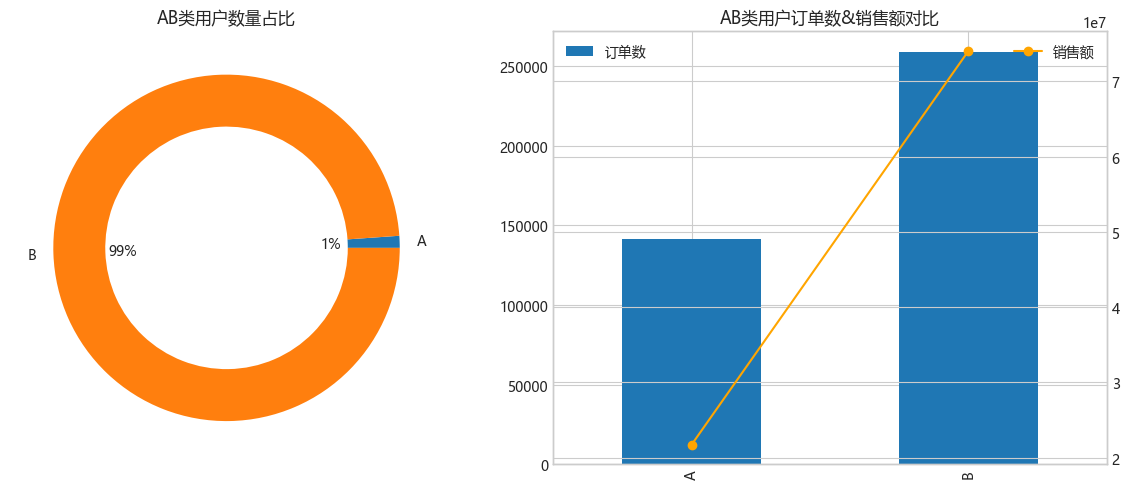

In [5]:
# 统计每个用户的订单数
user_record = df.groupby('user_id')['order_id'].count().sort_values(ascending=False)
print("用户订单数分布描述：")
print(user_record.describe())

# 拆分B类用户（订单数 < 30）
df_b = df.loc[df['user_id'].isin(user_record[user_record < 30].index)]
df_b['user_level'] = 'B'

# 拆分A类用户（订单数 >= 30）
df_a = df.loc[~df['user_id'].isin(list(df_b['user_id']))]
df_a['user_level'] = 'A'

# 合并分层结果
df_ab = pd.concat([df_a, df_b])

# 打印分层统计
print("\n用户分层统计：")
print(f"A类用户数：{df_a['user_id'].nunique()}，占比：{df_a['user_id'].nunique()/df['user_id'].nunique():.2%}")
print(f"B类用户数：{df_b['user_id'].nunique()}，占比：{df_b['user_id'].nunique()/df['user_id'].nunique():.2%}")
print(f"A类用户贡献销售额：{df_a['price'].sum():.2f}，占比：{df_a['price'].sum()/df['price'].sum():.2%}")

# 可视化：AB类用户占比 & 贡献对比
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# 用户数量占比饼图
df_ab.groupby('user_level')['user_id'].nunique().plot(
    kind='pie', title='AB类用户数量占比', ax=axs[0], 
    autopct='%.0f%%', ylabel='', wedgeprops={'width': 0.3}
)

# 销售额贡献堆叠图
ax1 = df_ab.groupby('user_level')['order_id'].count().plot(
    kind='bar', ax=axs[1], title='AB类用户订单数&销售额对比',
    xlabel='', label='订单数'
)
ax2 = ax1.twinx()
df_ab.groupby('user_level')['price'].sum().plot(
    kind='line', color='orange', ax=ax2, marker='o', label='销售额'
)
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()

✍️ 我的理解与疑问理解：
用户订单数分布极度不均，少量高频用户贡献了大量销售额，直接全量分析会被极端值干扰，无法反映普通用户的真实行为。

以 30 单为阈值，98.9% 的用户被划到 B 类普通用户，聚焦 B 类分析更贴合门店主流客群的运营需求。
A 类用户仅 1% 却贡献近 20% 销售额，属于高价值 KA 客户，适合单独做精细化运营。

疑问 / 待验证：
30 单的阈值是凭经验定的，还是有数据依据？有没有更科学的分层方法？
A 类用户会不会是刷单、渠道批发等异常数据？

三、人群画像分析（地区、性别、年龄）
🤔 思考问题

地区、性别、年龄这三个维度，分别能指导什么具体的运营动作？

从结果看，消费高度集中在一线城市，对应什么业务策略？

年龄和性别维度有没有明显的用户特征？对选品、营销投放有什么参考价值？

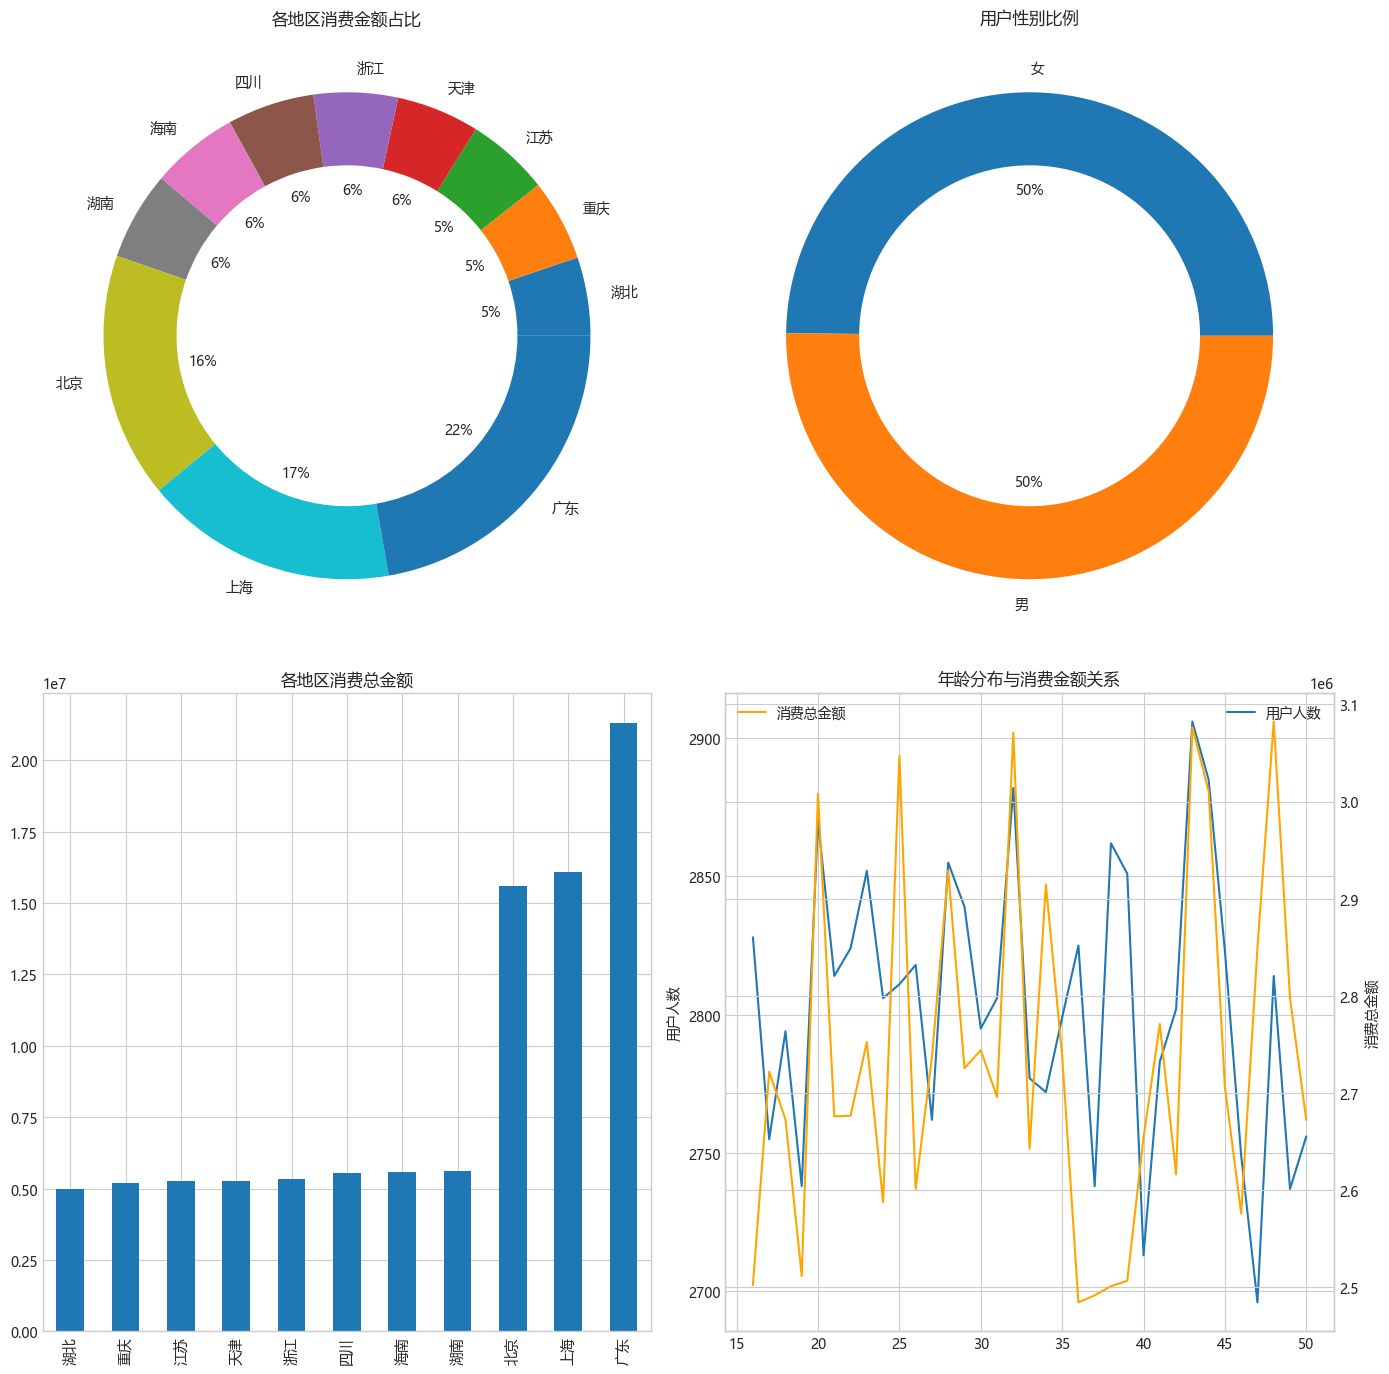

In [6]:
fig, axs = plt.subplots(2, 2, figsize=(14, 14))

# 1. 消费金额地区分布-饼图
df.groupby('local')['price'].sum().sort_values().plot(
    kind='pie', ylabel='', ax=axs[0, 0], autopct='%.0f%%',
    wedgeprops={'width': 0.3}, title='各地区消费金额占比'
)

# 2. 性别比例
df.groupby('sex')['user_id'].nunique().plot(
    kind='pie', title='用户性别比例', ax=axs[0, 1], ylabel='',
    autopct='%.0f%%', wedgeprops={'width': 0.3}
)

# 3. 消费金额地区分布-条形图
df.groupby('local')['price'].sum().sort_values().plot(
    kind='bar', ax=axs[1, 0], xlabel='', title='各地区消费总金额'
)

# 4. 年龄-人数&消费金额双轴图
ax1 = df.groupby('age')['user_id'].nunique().rename('用户人数').plot(
    title='年龄分布与消费金额关系', ylabel='用户人数',
    ax=axs[1, 1], xlabel='', legend=1
)
ax2 = ax1.twinx()
df.groupby('age')['price'].sum().rename('消费总金额').plot(
    ax=ax2, color='orange', ylabel='消费总金额', legend=True, xlabel=''
)
ax2.legend(loc=2)

plt.tight_layout()
plt.show()

✍️ 我的理解与疑问

理解：

北上广地区消费能力最强，贡献了过半销售额，营销预算和库存资源应该优先向一线城市倾斜。

性别分布相对均衡，没有明显的性别偏好，选品不用过度偏向单一性别。

年龄维度存在异动数据，部分年龄段数据异常，参考价值有限，后续可以进一步清洗验证。

疑问 / 待验证：

地区数据只有省份 / 直辖市，能不能下沉到城市级别分析？

年龄字段的异常值是数据采集问题，还是真实用户分布？


四、产品品牌分析、

🤔 思考问题

是否要分析 Top10 品牌的销售额占比？能反映什么业务问题？

头部品牌集中度过高，对门店来说有什么风险？有什么优化方向？

A、B 两类用户的品牌偏好有没有差异？对分层运营有什么指导？

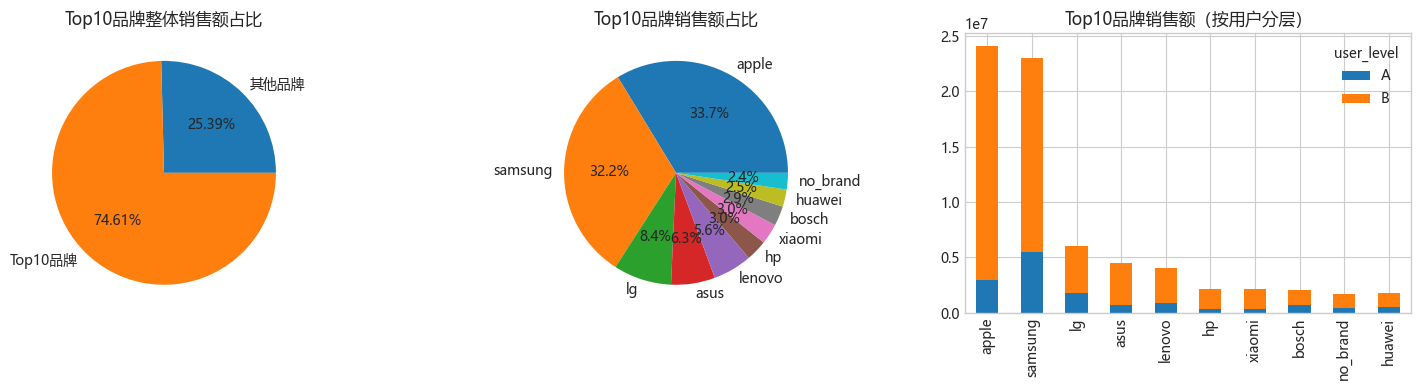

In [7]:
fig, axs = plt.subplots(1, 3, figsize=(15, 4))

# 1. Top10品牌 vs 其他 整体占比
top_sales = df.groupby('brand')['price'].sum().sort_values(ascending=False).head(10).sum()
total_sales = df['price'].sum()
pd.Series({'其他品牌': total_sales - top_sales, 'Top10品牌': top_sales}).plot(
    kind='pie', title='Top10品牌整体销售额占比',
    autopct='%.2f%%', ax=axs[0], ylabel=''
)

# 2. Top10品牌各自占比
df.groupby('brand')['price'].sum().sort_values(ascending=False).head(10).plot(
    kind='pie', autopct='%.1f%%', ax=axs[1], ylabel='',
    title='Top10品牌销售额占比'
)

# 3. AB类用户Top10品牌销售额堆叠图
df_ab.groupby(['brand', 'user_level'])['price'].sum().unstack()\
    .sort_values(by=['B'], ascending=False).head(10).plot(
    stacked=True, kind='bar', title='Top10品牌销售额（按用户分层）',
    ax=axs[2], xlabel=''
)

plt.tight_layout()
plt.show()

✍️ 我的理解与疑问

理解：

销售额高度集中在头部两大品牌，CR2 接近 50%，门店对头部品牌依赖度较高。

和整体市场份额对比差异大，说明门店选品偏窄，非头部品牌有很大的挖掘空间。

非专卖店场景下，丰富中腰部品牌的选品，是提升销售额的潜在方向。

疑问 / 待验证：

头部品牌销量高，是因为用户偏好，还是因为门店主推、给了更多资源位？

能不能分析各品牌的客单价、复购率，判断哪些品牌值得重点扶持？

五、销量与运营分析

🤔 总问题

销售额呈现「4-8 月快速增长，8 月后快速下滑」的趋势，核心原因是什么？从哪些维度拆解验证？

5.1 月度销售趋势拆解

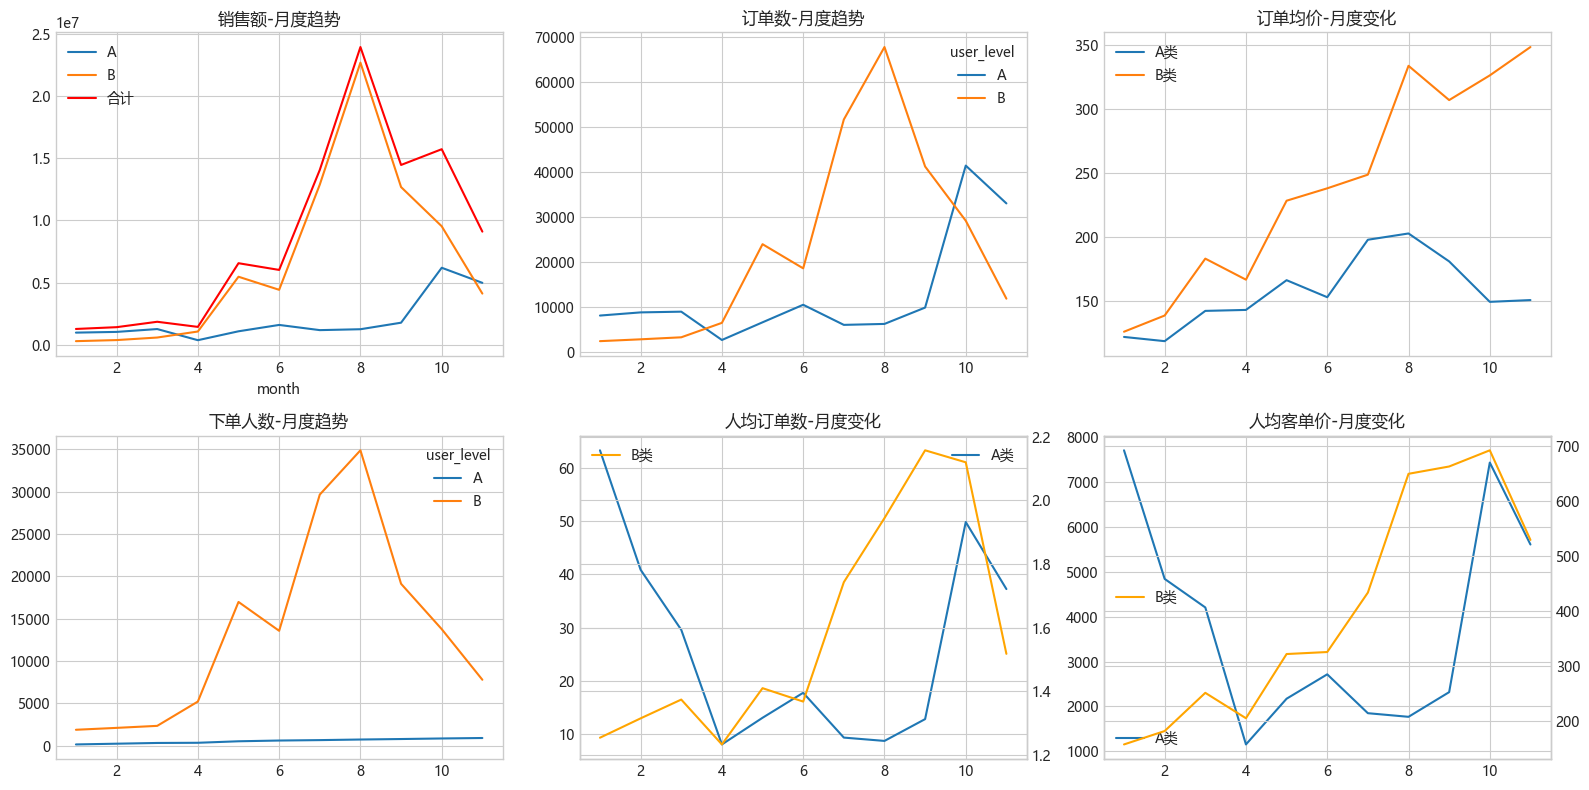

In [8]:
fig, axs = plt.subplots(2, 3, figsize=(16, 8))

# 1. 销售额月度趋势
df_ab.groupby(['month', 'user_level'])['price'].sum().unstack().plot(
    grid=True, title='销售额-月度趋势', xlabel='', ax=axs[0, 0]
)
df_ab.groupby('month')['price'].sum().rename('合计').plot(
    ax=axs[0, 0], color='r'
).legend(loc=2)

# 2. 订单数月度趋势
df_ab.groupby(['month', 'user_level'])['order_id'].count().unstack().plot(
    grid=True, title='订单数-月度趋势', xlabel='', ax=axs[0, 1]
)

# 3. 订单均价月度变化
(df_a.groupby('month')['price'].sum() / df_a.groupby('month')['order_id'].count()).rename('A类').plot(
    xlabel='', ax=axs[0, 2]
)
(df_b.groupby('month')['price'].sum() / df_b.groupby('month')['order_id'].count()).rename('B类').plot(
    grid=True, title='订单均价-月度变化', xlabel='', ax=axs[0, 2]
).legend(loc=2)

# 4. 下单人数月度趋势
df_ab.groupby(['month', 'user_level']).user_id.nunique().unstack().plot(
    grid=True, title='下单人数-月度趋势', xlabel='', ax=axs[1, 0]
)

# 5. 人均订单数月度变化
ax2 = (df_a.groupby('month')['order_id'].count() / df_a.groupby('month').user_id.nunique()).rename('A类').plot(
    grid=True, xlabel='', ax=axs[1, 1], legend=1
)
(df_b.groupby('month')['order_id'].count() / df_b.groupby('month').user_id.nunique()).rename('B类').plot(
    title='人均订单数-月度变化', xlabel='', ax=ax2.twinx(), color='orange'
).legend(loc=2)

# 6. 人均客单价月度变化
ax1 = (df_a.groupby('month')['price'].sum() / df_a.groupby('month').user_id.nunique()).rename('A类').plot(
    grid=True, xlabel='', ax=axs[1, 2], legend=1
)
(df_b.groupby('month')['price'].sum() / df_b.groupby('month').user_id.nunique()).rename('B类').plot(
    title='人均客单价-月度变化', xlabel='', ax=ax1.twinx(), color='orange'
).legend(loc=6)

plt.tight_layout()
plt.show()

5.2 用户活跃度变化（新用户 / 活跃用户 / 流失用户）

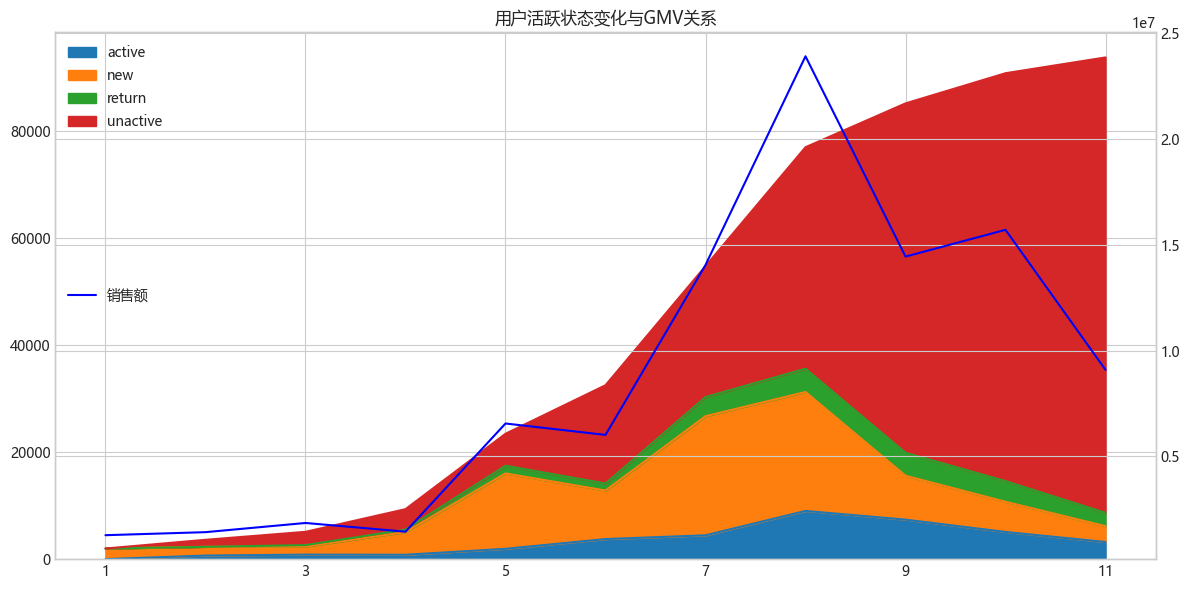

In [9]:
columns_month = df['month'].sort_values().astype('str').unique()

def active_status(x):
    status = []
    for i in range(len(columns_month)):
        if x[i] == 0:
            if i == 0:
                status.append('unreg')
            else:
                status.append('unreg') if status[i-1] == 'unreg' else status.append('unactive')            
        else:
            if i == 0:
                status.append('new')
            else:
                if status[i-1] == 'unreg':
                    status.append('new') 
                else:
                    status.append('return') if status[i-1]=='unactive' else status.append('active')
    return pd.Series(status, index = columns_month)

# 构建用户月度消费矩阵
order_record = df.pivot_table(
    index='user_id', columns='month', values='price', aggfunc='sum'
).fillna(0).applymap(lambda i: 1 if i>0 else 0)
order_record.columns = columns_month

# 计算每月用户状态
user_active_status = order_record.apply(active_status, axis=1)

# 可视化
ax1 = user_active_status.apply(lambda x: pd.value_counts(x)).drop('unreg').fillna(0).T.plot(
    kind='area', figsize=(12, 6), title='用户活跃状态变化与GMV关系'
)
df_ab.groupby([df_ab['event_time'].dt.month])['price'].sum().rename('销售额').plot(
    ax=ax1.twinx(), grid=True, color='b', xlabel='', use_index=False
).legend(loc=6)

plt.tight_layout()
plt.show()

5.3 复购率与二次下单间隔

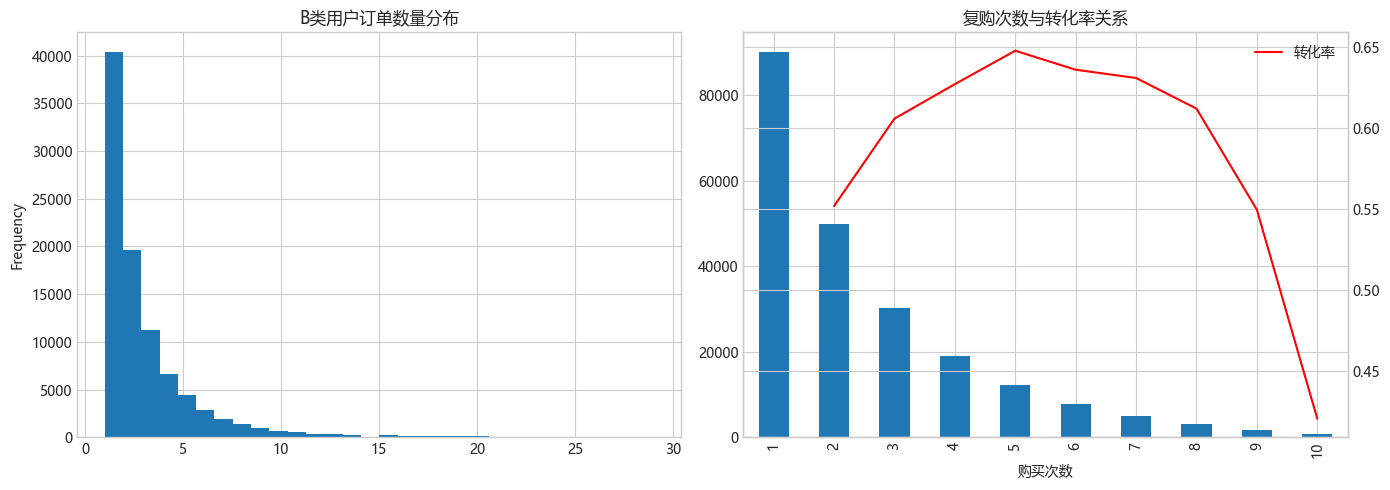

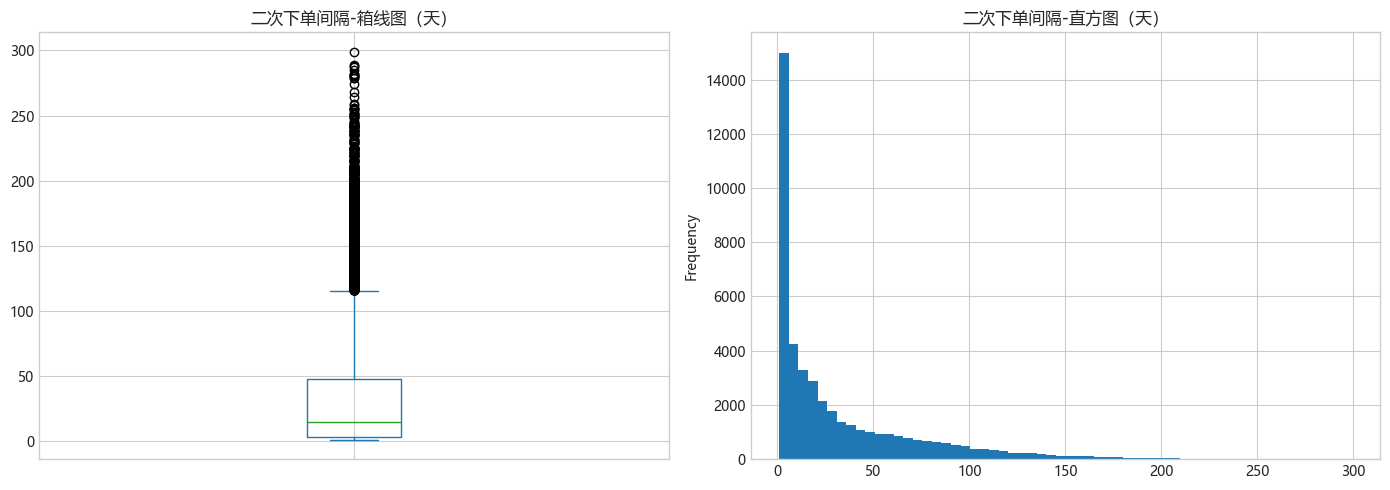

In [10]:
# 复购率分布
order_totll = df_b.groupby('user_id').agg({'order_id':pd.Series.count,'price':np.max}).groupby('order_id')['price'].count().head(10)
order_fq = []
for i in range(10):
    a = order_totll.iloc[i:].sum()
    order_fq.append(a)
order_fq = pd.Series(order_fq, index=list(range(1,11)))

fig, axs = plt.subplots(1, 2, figsize=(14, 5))

# 订单数量分布直方图
df_b.groupby('user_id')['order_id'].count().plot(
    kind='hist', bins=30, ax=axs[0], title='B类用户订单数量分布'
)

# 复购转化率
ax1 = order_fq.head(10).plot(kind='bar', ax=axs[1], xlabel='购买次数')
(order_fq.pct_change(periods=1)+1).rename('转化率').plot(
    use_index=False, color='r', title='复购次数与转化率关系',
    grid=True, ax=ax1.twinx(), legend=1
)

plt.tight_layout()
plt.show()

# 二次下单间隔分布
order_2b = df_b[['user_id','event_time','order_id']].reset_index(drop = True)
order_2b = order_2b.groupby(by=['user_id','event_time'],as_index=False)['order_id'].count()
order_2b = order_2b.pivot_table(index='user_id',columns='event_time',values='order_id').fillna(0)

def data_count(x): 
    fig =0
    for i in range(len(x)):
        if x.iloc[i] !=0:
            if fig!=1 :
                fig+=1 
                a=i
            else:
                a=i-a
                return a

second_order = order_2b.apply(data_count, axis=1) 

fig, axs = plt.subplots(1, 2, figsize=(14, 5))
second_order.plot(kind="box", title='二次下单间隔-箱线图（天）', ax=axs[0])
second_order.plot(kind="hist", title='二次下单间隔-直方图（天）', ax=axs[1], bins=60)

plt.tight_layout()
plt.show()

✍️ 我的理解与疑问

理解：

8 月后销售额下滑的核心原因是下单人数和订单量流失，不是客单价下降。

4-8 月的增长主要靠新用户持续导入，8 月后新用户数急剧下滑，直接带动销售额下跌。

B 类用户的客单价、人均订单数一直在稳步上升，说明老用户价值在持续释放，会员运营效果不错。

约 70% 的用户二次复购发生在 50 天以内，营销触达应该重点放在用户首购后的 50 天黄金周期内。

疑问 / 待验证：

4-8 月的新用户暴增是因为做了引流活动吗？8 月后下滑是活动结束了还是渠道出了问题？

二次复购率 55% 高于行业平均，是数据样本偏差，还是门店会员运营真的做得好？

六、RFM 会员价值分析

🤔 思考问题

R、F、M 三个指标分别代表用户的什么价值？为什么选这三个维度做用户分层？

分层阈值（R≤30 天、F≥3 单、M≥1257 元）是怎么确定的？合理吗？

8 类用户分别对应什么运营策略？当前门店哪类用户最多，是运营重点？


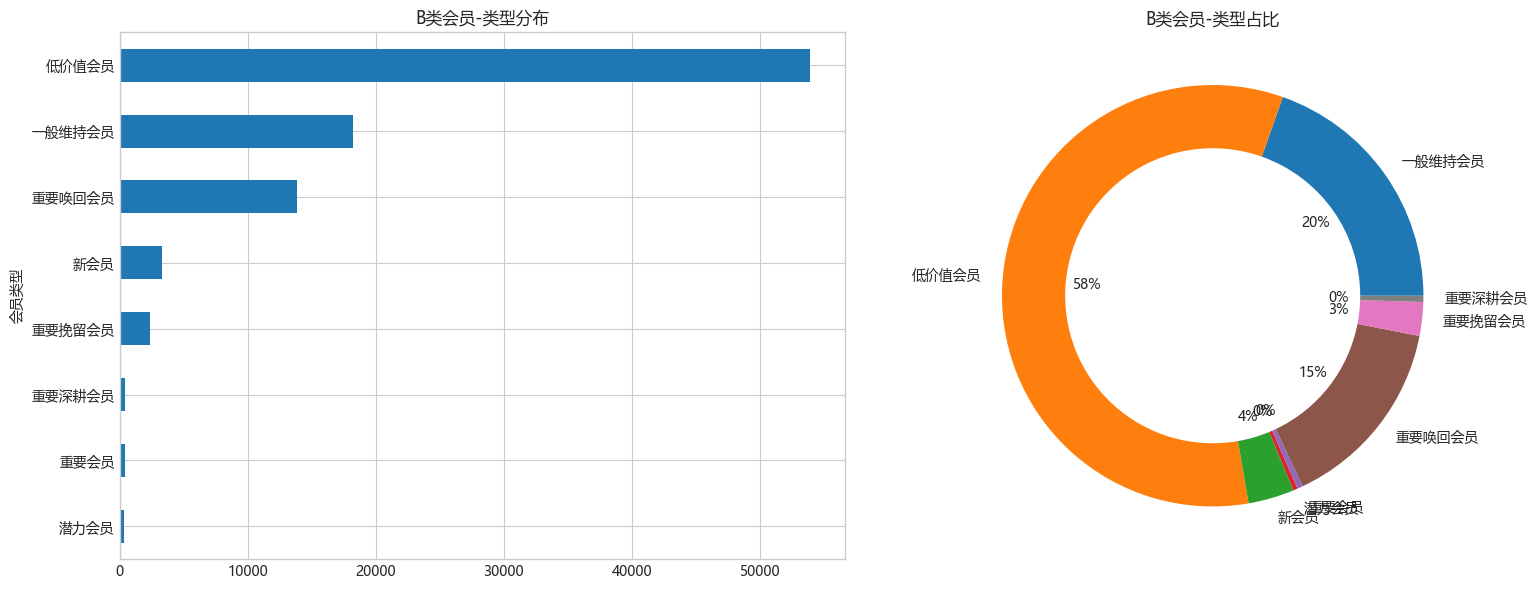

RFM会员分层统计：
会员类型
低价值会员     53936
一般维持会员    18182
重要唤回会员    13832
新会员        3276
重要挽留会员     2400
重要深耕会员      440
重要会员        395
潜力会员        318
Name: count, dtype: int64


In [11]:
import re

# 计算R：最近一次消费距截止日的天数
b_r = df_b.groupby('user_id')['event_time'].min().map(
    lambda i : pd.to_datetime('2020-11-21').to_period('D')-i
)
R = b_r.astype('str').map(lambda i: re.compile(r'\d*').findall(i)[1])
R.loc[b_r.astype('str').map(lambda i: re.compile(r'\d*').findall(i)[1])=='']=1
R = R.astype('int32')

# 计算F：消费频次
F = df_b.groupby('user_id')['order_id'].count()

# 计算M：消费总金额
M = df_b.groupby('user_id')['price'].sum()

# RFM分层映射
dic_rfm ={
    '111':'重要会员：倾斜更多资源，VIP服务，个性化服务，附加销售',
    '011':'重要唤回会员：DM营销，提供有用的资源，通过新的商品召唤回',
    '101':'重要深耕会员：交叉销售，制定会员忠诚度计划，推荐其他商品',
    '001':'重要挽留会员：重点联系或摆放，提高留存率',
    '110':'潜力会员：向上营销，销售价值更高的商品',
    '100':'新会员：提供免费试用，提高会员兴趣，创建品牌知名度',
    '010':'一般维持会员：积分制，分享宝贵资源，以折扣推荐热门商品',
    '000':'低价值会员：恢复会员兴趣，否则暂时放弃'
}

def RFM_score(x):
    r='1' if x[0]<= 30 else '0'
    f='1' if x[1]>= 3 else '0'
    m='1' if x[2]>=1257 else '0'
    return dic_rfm[r+f+m]

b_rfm = pd.concat([R,F,M],axis=1).apply(RFM_score,axis=1)
B_RFM = pd.concat([
    b_rfm.map(lambda i: i.split('：')[0]).rename('会员类型'),
    b_rfm.map(lambda i: i.split('：')[-1]).rename('营销策略')
], axis=1)

# 可视化
fig, axs = plt.subplots(1, 2, figsize=(16, 6))
B_RFM.groupby('会员类型')['营销策略'].count().sort_values().plot(
    kind='barh', title='B类会员-类型分布', xlabel='', ax=axs[0], grid=1
)
B_RFM.groupby('会员类型')['营销策略'].count().plot(
    kind='pie', title='B类会员-类型占比', autopct='%.0f%%',
    ax=axs[1], wedgeprops={'width': 0.3}, ylabel=''
)

plt.tight_layout()
plt.show()

# 打印各类型用户数量
print("RFM会员分层统计：")
print(B_RFM['会员类型'].value_counts().sort_values(ascending=False))

✍️ 我的理解与疑问

理解：

RFM 模型从「最近消费时间、消费频次、消费金额」三个维度量化用户价值，是零售行业最经典的用户分层方法。

门店有较多的「重要唤回会员」，这部分用户价值高但正在流失，是运营召回的重点人群。

基于 RFM 标签做差异化营销，比统一发券的效率更高，能提升 ROI。

疑问 / 待验证：

三个维度的阈值都是用均值 / 经验值定的，有没有更科学的分箱方法（比如四分位数）？

三个维度的权重一样，实际业务里消费金额是不是应该权重更高？


七、整体分析总结

一、核心结论

销售趋势：4-8 月增长由新用户拉动，8 月后下滑源于获客断层，业务整体偏流量驱动，抗波动能力较弱。

用户结构：二八效应显著，不足 2% 的高频用户贡献近 20% 销售额，普通用户是营收基本盘，分层运营必要性强。

产品结构：头部品牌集中度高，Top2 贡献近半数销售额，中腰部品牌潜力未释放，选品宽度不足。
会员价值：高价值流失用户占比偏高，唤回空间大；用户二次复购黄金周期为 50 天，触达节奏仍可优化。

二、运营建议

流量端：复盘 8 月后获客下滑原因，拓展新渠道，降低单一流量依赖。

用户端：分层精准触达 —— 重点唤回高价值流失用户，引导新用户完成首转复，给高频用户配套 VIP 权益。

产品端：扶持潜力中腰部品牌，丰富价格带，分散头部品牌依赖风险。

会员端：基于 RFM 细化会员权益体系，拉长用户生命周期价值。

三、分析局限性

缺少成本、渠道、用户行为等数据，仅覆盖销售额维度，无法测算盈利与 ROI。

用户分层、RFM 阈值以经验值为主，未做更严谨的分箱验证。

无行业对标数据，无法判断运营水平的行业位置。

时间周期较短，结论存在时效性局限。

四、可拓展方向

补充成本数据，做利润维度拆解

分析品类复购关联，优化搭配推荐

搭建销量预测模型，辅助库存决策

设计 AB 测试，量化验证运营策略效果